In [1]:
import numpy as np

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

# bigram language model

* In a bigram model, we always work with two characters at a time.
* We only look at one character and try to predict the next character in the sequence.
* Although we may have a lot of information, we are always just looking at the previous character to predict the next one, making this a very simple and weak language model."

In [6]:
for w in words[:1]:
    for ch1, ch2 in zip (w, w[1:]):
        print(ch1,ch2)

e m
m m
m a


In [7]:
w

'emma'

In [8]:
w[1:]

'mma'

In [9]:
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] # so in this way we can detect the most of start and end char
    for ch1, ch2 in zip (chs, chs[1:]):
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


* we are gonna count how often any one of these combinations occurs in the training set

In [10]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] # so in this way we can detect the mot of start and end char
    for ch1, ch2 in zip (chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [11]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

* In this point we can figure out a has a potential being last char. (('a', '< E >'): 3,)
* now lets check on all words

In [12]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # so in this way we can detect the mot of start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [13]:
#b

In [14]:
sorted(b.items(), key = lambda kv: -kv[1]) # lets check common ones, -kv[1]-> 1 means count number

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

* we're gonna store this information in 3d array
* rows = first chc, second = second chc

In [15]:
import torch

/opt/anaconda3/envs/torch_base/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
a = torch.zeros((3,5), dtype = torch.int32) # 3x5 array
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [17]:
a.dtype

torch.int32

* Tensors allow us to manipulate individual entries efficiently.

In [18]:
a[1,3] = 2

In [19]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 2, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [20]:
N = torch.zeros((28,28), dtype = torch.int32) # 26 letter and 2 mark sign


In [21]:

for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # so in this way we can detect the most of repeat start and end char
    for ch1, ch2 in zip (chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

* now we need the lookup table from char to int

In [22]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)} # string to integer (stoi)
stoi['<S>'] = 26 # we need to add two mark manually 
stoi['<E>'] = 27
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [23]:
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

N


tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

* Lets try to visualize nicer

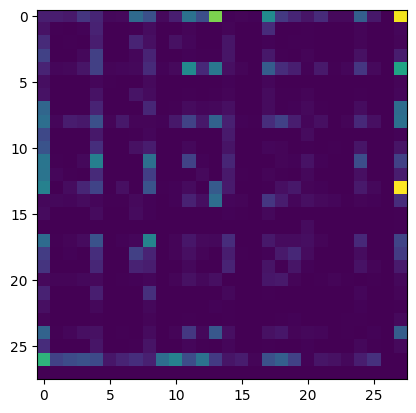

In [24]:
import matplotlib.pyplot as plt
plt.imshow(N)

* Still looking ugly...
* First off all we are going to need to invert stoi to reverse dictionary (stoi -> itos)

In [25]:
itos = {i:s for s,i in stoi.items()}
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<S>',
 27: '<E>'}

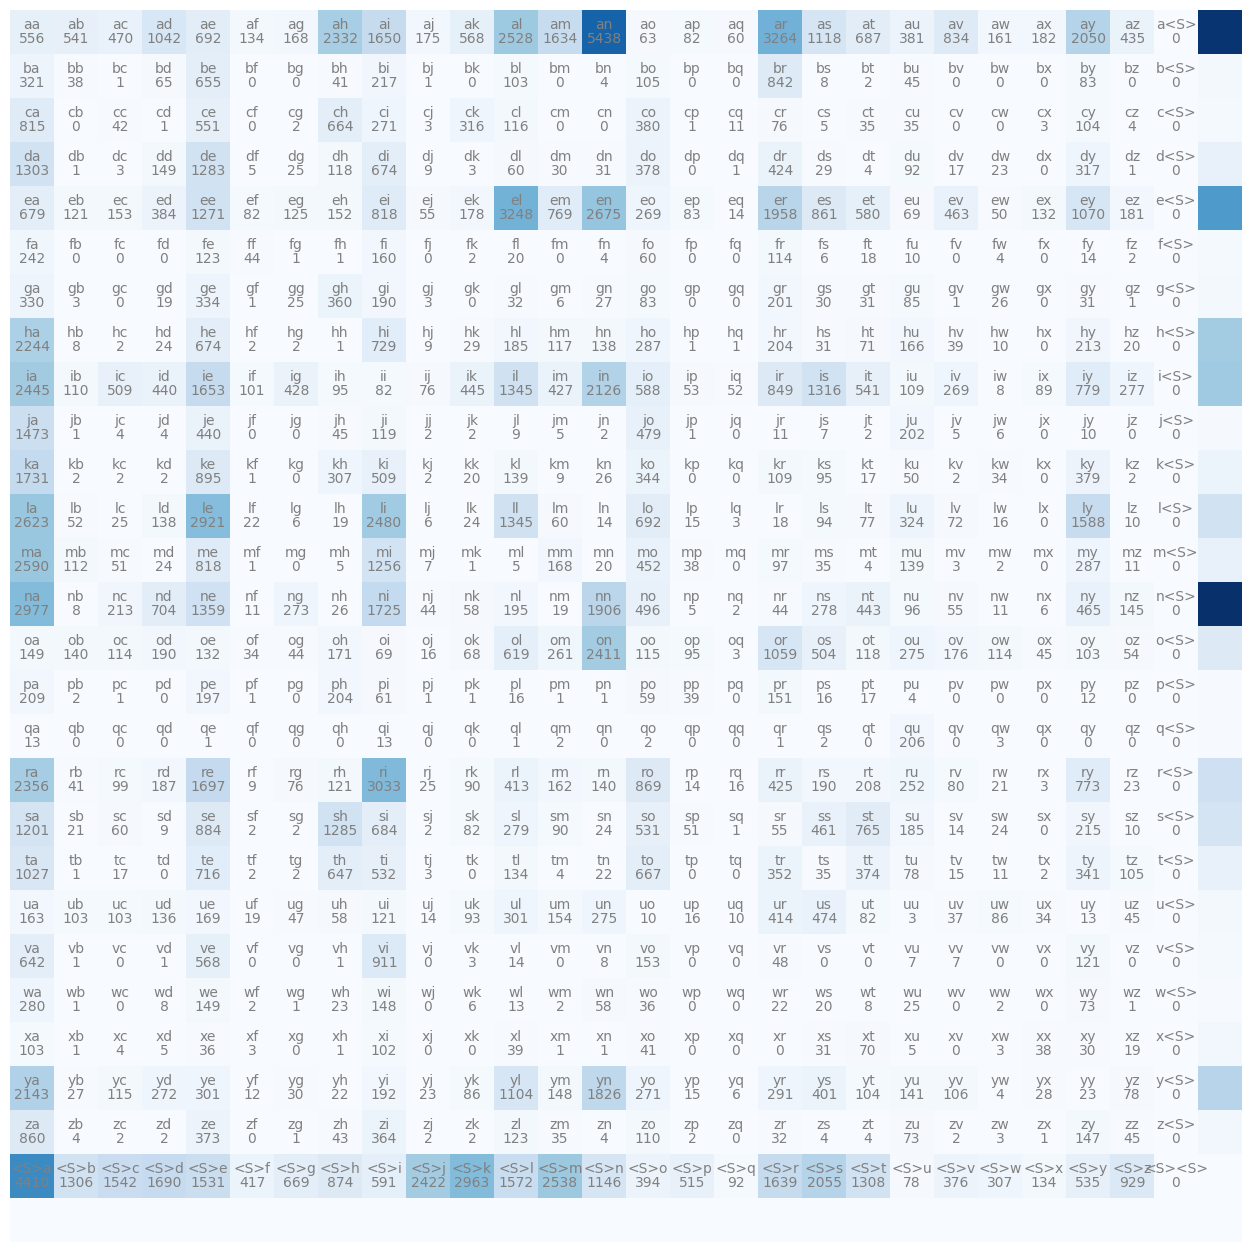

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

* we have a some problem on unique char in plot lets fix it

In [27]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [28]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [29]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

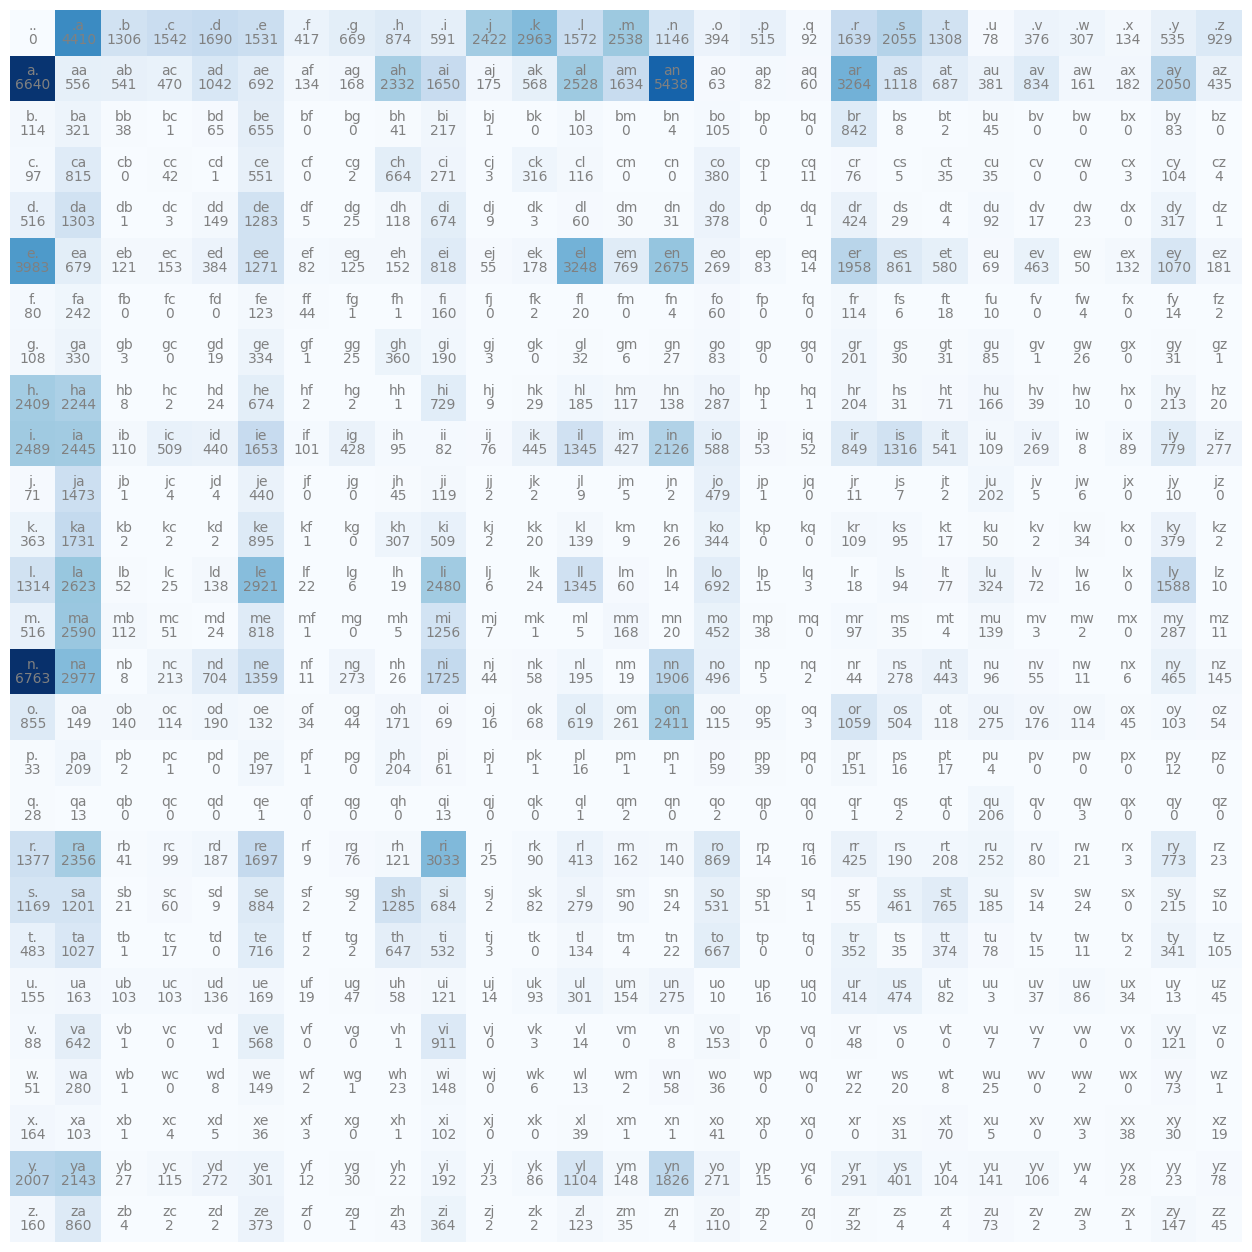

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [31]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [32]:
p = N[0].float() # probabilty
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

* Now p giving us the probabilty any single char to be first char of a word

In [33]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator =g)
p = p /p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

* https://pytorch.org/docs/stable/generated/torch.multinomial.html

In [34]:
torch.multinomial(p, num_samples=20, replacement=True,generator =g)
# like this method we are always getting deterministic result

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [35]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
print(ix)
itos[ix]

1


'a'

* now we have a first letter lets check it others in loop

In [36]:
g = torch.Generator().manual_seed(2147483647)
ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
    print(itos[ix])
    if ix == 0: #thats mean end token
        break

m
o
r
.


* our word is 'mor.'

In [37]:
g = torch.Generator().manual_seed(2147483647)
ix = 0
out = []

while True:

    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
    out.append(itos[ix])
    if ix == 0: #thats mean end token
        break
print(''.join(out))

mor.


* we are always getting same result because of generator lets change it

In [38]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):

    ix = 0
    out = []

    while True:

        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.
odaren.
iaddash.
h.
jhinatien.
egushl.
h.
br.
a.
jayn.
ilemannariaenien.
be.
f.
akiinela.
trttanakeroruceyaaxatona.
lamoynayrkiedengin.


* Oops. These outputs don't look good (for example, single letters like 'h' as words). The reason is that our model sometimes predicts 'h' as the first letter, but 'h' is not often used as a first character.

In [39]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):

    ix = 0
    out = []

    while True:

        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.
odaren.
iaddash.
h.
jhinatien.
egushl.
h.
br.
a.
jayn.
ilemannariaenien.
be.
f.
akiinela.
trttanakeroruceyaaxatona.
lamoynayrkiedengin.


In [40]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):

    ix = 0
    out = []

    while True:

        # p = N[ix].float()
        # p = p / p.sum()
        p = torch.ones(27) /27
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

qvsaayxbqrqmyqwuznivanukotdjvdhd.
qnoymtzduqkatdetkpfjdgigvlejfkrsqlwnirghhzwlu.
idcx.
cekmzucjnjoeovjvrggqrjr.
cfbhabkslpokc.
xtxwbpmknuusxdgzfexhwqpldpdnwzvkyxsqjforqqpfxstwkfoufhvwfhmsuyyotvcvvqpfcbydjcouhkajkhqnnpqmmllaordqy.
gszpw.
zlgijinangzzuulsyvqrufuawavsdbnwvlmrypvgrsfgpshgnmwafqmsjdvbhngvoiigxhkwdltrdkwnagzyknqv.
lfstdqigvncdoidetsukgdp.
cfpjsxeqjcsmjwguzes.
woflfjxflylgbegpjdpovdtw.
dlzysqtrbhxhcdneiuum.
xtyslfbmaboaanyjpojuujflcsaucqcgtjmlzqtbaisvxrtgupkppigxudejdzsroqeigovuxmvt.
jlxfolkozci.
tkhdivkdifaxcevlpktkwwvuxlymtwylgpzauwdvxfvbooflddphmjeomjgjcqeqwt.
.
wlxclcjbm.
quuyijtnzmycshclormjyrerqslomdrlbuwqnlmitbrmqhtbdwbyvlsmwnborwcdhjotezwnsxuvffvinrmedelubhdfgtavxqfgmnyqrygyevxaapbjtnwfnwewqxerdytttvfo.
iauarz.
tynoqkyp.


* Now we have a uniform distribution, so everything is equal. Our outputs are coming from an untrained model (where every character has the same probability), and they are garbage.

* first of all we will define new P because the old version of P in our model is not working efficient

In [41]:
P = N.float()
# P /P.sum() # 

In [42]:
P.sum() # p.sum is a huge number we have to find new way

tensor(228146.)

In [43]:
P.sum(0, keepdim=True) 

tensor([[32033., 33885.,  2645.,  3532.,  5496., 20423.,   905.,  1927.,  7616.,
         17701.,  2900.,  5040., 13958.,  6642., 18327.,  7934.,  1026.,   272.,
         12700.,  8106.,  5570.,  3135.,  2573.,   929.,   697.,  9776.,  2398.]])

In [44]:
P.sum(0, keepdim=True) .shape

torch.Size([1, 27])

* now we have a sum of row vector not sum of all
* but actually we dont wanna [1,27] dimension we want a another way

In [45]:
P.sum(1, keepdim=True) .shape

torch.Size([27, 1])

In [46]:
P.sum(1, keepdim=True)

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])

In [47]:
P = N.float()
P = P /P.sum(1, keepdim= True) 

* this section contains broadcasting sementics read the article (P = P /P.sum(1, keepdim= True))
* https://pytorch.org/docs/stable/notes/broadcasting.html
* !!!CHECKPOINT

In [48]:
P[0].sum()

tensor(1.)

In [49]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):

    ix = 0
    out = []

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.
odaren.
iaddash.
h.
jhinatien.
egushl.
h.
br.
a.
jayn.
ilemannariaenien.
be.
f.
akiinela.
trttanakeroruceyaaxatona.
lamoynayrkiedengin.


* if we dont use keepdims=True parameter lets check whats gonna  happen.(broadcasting  disable)

In [50]:
P = N.float()
P/=P.sum(1) 

In [51]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):

    ix = 0
    out = []

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

prrabuxclssoxxxxzontantorsemrdef.
ppprluzavilavegunjemahekwiffffksslyndomdeyviu.
jadw.
chinzwamikojowivighoumo.
ch.
h.
bismoricaysuwarliovouxigydeygwrophognuzylywttlequssphwttylequghuwelluwyzovofrusredaych.
mphialigrorotopopaqudox.
guzowazlelihmandyzyuppstttugububrrdaowupouxxxsstharrigjowahopph.
uchlewondextowbluthixxahzziotw.
ketthondurceriddrrtnchoachnetyclicophvevydr.
wokiffthizlebelonarowdrubdizzusttelyh.
dkeluwkaxxzuquckabrabryloriuwiffevavarbevingyppe.
htwyqujusiqulexxiemazutrohekowuxxxx.
jowerjoryak.
rigelwidegaxhawiquwixxxxymynprylery.
sthuxowaqugieerhkhaqumbicohowubaxxxffeman.
ppprikurynzaulblouquxxlquwipogtoduwropphucopphtcexeyuququraquwademmphzynoxxxolwhlsoidditaidekubryokengwrquiyduxcaraluruglycquxlteysttxor.
javatz.
swniquxx.


* complately meaningless... Thats why broadcasting is important 
* this extra '1' dimension is necessary 
* one more detail we should use P/=P.sum() because otherwise old school expression is creating a new tensor and its not efficency

* Lets evaluate the quality of this model 

In [52]:
P = N.float()
P = P /P.sum(1, keepdim= True) 

g = torch.Generator().manual_seed(2147483647)
for i in range(5):

    ix = 0
    out = []

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.


In [53]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        print(f'{ch1}{ch2}:{prob:.4f}')

.e:0.0478
em:0.0377
mm:0.0253
ma:0.3899
a.:0.1960
.o:0.0123
ol:0.0780
li:0.1777
iv:0.0152
vi:0.3541
ia:0.1381
a.:0.1960
.a:0.1377
av:0.0246
va:0.2495
a.:0.1960


* We have 27 possible characters or tokens, and if everything is equally likely, each one has a probability of 0.03 (1/27 = 0.03). So, any probability above 4% means we have learned something useful from these bigrams. If you have a perfect model, these probabilities should be 1 because the model correctly predicts what will come next, especially on the training set.

* how can we summarize these probabilities? -> Likelyhood function
* https://en.wikipedia.org/wiki/Likelihood_function
* Likelihood is the product of these probabilities. When training the model, the likelihood should be as high as possible, indicating a good model.

* for example we have  a 3 probs(a,b,c). 
* * likelihood prob -> a * b* c
* * log likelihood probs -> log(a * b* c) -> log(a) + log(b) + log(c)

In [54]:
log_likelihood = 0.0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')

.e:0.0478-3.0408
em:0.0377-3.2793
mm:0.0253-3.6772
ma:0.3899-0.9418
a.:0.1960-1.6299
.o:0.0123-4.3982
ol:0.0780-2.5508
li:0.1777-1.7278
iv:0.0152-4.1867
vi:0.3541-1.0383
ia:0.1381-1.9796
a.:0.1960-1.6299
.a:0.1377-1.9829
av:0.0246-3.7045
va:0.2495-1.3882
a.:0.1960-1.6299
log_likelihood=tensor(-38.7856)


* How high can the log-likelihood get? If all probabilities are 1, then the log-likelihood will be 0. When all probabilities are lower, the log-likelihood becomes more and more negative. However, we don't want this because, as a loss function, lower values are better since we try to minimize the loss. So, we should invert this function to resemble a loss function. We need a negative log-likelihood function.

In [55]:
log_likelihood = 0.0
n_l_l = -log_likelihood
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')

.e:0.0478-3.0408
em:0.0377-3.2793
mm:0.0253-3.6772
ma:0.3899-0.9418
a.:0.1960-1.6299
.o:0.0123-4.3982
ol:0.0780-2.5508
li:0.1777-1.7278
iv:0.0152-4.1867
vi:0.3541-1.0383
ia:0.1381-1.9796
a.:0.1960-1.6299
.a:0.1377-1.9829
av:0.0246-3.7045
va:0.2495-1.3882
a.:0.1960-1.6299
log_likelihood=tensor(-38.7856)
n_l_l=tensor(38.7856)


* negative_log_likelyhood very good for us because lowest it can get is zero and the higher it can get worse off predictions

In [56]:
log_likelihood = 0.0
n = 0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        n+=1
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')
print( f'{n_l_l/n}')

.e:0.0478-3.0408
em:0.0377-3.2793
mm:0.0253-3.6772
ma:0.3899-0.9418
a.:0.1960-1.6299
.o:0.0123-4.3982
ol:0.0780-2.5508
li:0.1777-1.7278
iv:0.0152-4.1867
vi:0.3541-1.0383
ia:0.1381-1.9796
a.:0.1960-1.6299
.a:0.1377-1.9829
av:0.0246-3.7045
va:0.2495-1.3882
a.:0.1960-1.6299
log_likelihood=tensor(-38.7856)
n_l_l=tensor(38.7856)
2.424102306365967


* now our job is find the parameters that minimize the nll
* GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
* equivalent to maximizing the log likelihood (because log is monotonic)
* equivalent to minimizing the negative log likelihood
* equivalent to minimizing the average negative log likelihood

* log(a*b*c) = log(a) + log(b) + log(c)

In [57]:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        n+=1
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')
print( f'{n_l_l/n}')

.e:0.0478-3.0408
em:0.0377-3.2793
mm:0.0253-3.6772
ma:0.3899-0.9418
a.:0.1960-1.6299
.o:0.0123-4.3982
ol:0.0780-2.5508
li:0.1777-1.7278
iv:0.0152-4.1867
vi:0.3541-1.0383
ia:0.1381-1.9796
a.:0.1960-1.6299
.a:0.1377-1.9829
av:0.0246-3.7045
va:0.2495-1.3882
a.:0.1960-1.6299
.i:0.0184-3.9927
is:0.0743-2.5990
sa:0.1482-1.9094
ab:0.0160-4.1373
be:0.2476-1.3958
el:0.1590-1.8386
ll:0.0964-2.3397
la:0.1879-1.6717
a.:0.1960-1.6299
.s:0.0642-2.7465
so:0.0655-2.7256
op:0.0120-4.4250
ph:0.1988-1.6153
hi:0.0957-2.3463
ia:0.1381-1.9796
a.:0.1960-1.6299
.c:0.0481-3.0337
ch:0.1880-1.6713
ha:0.2946-1.2220
ar:0.0963-2.3400
rl:0.0325-3.4259
lo:0.0496-3.0042
ot:0.0149-4.2082
tt:0.0671-2.7009
te:0.1285-2.0515
e.:0.1950-1.6346
.m:0.0792-2.5354
mi:0.1891-1.6655
ia:0.1381-1.9796
a.:0.1960-1.6299
.a:0.1377-1.9829
am:0.0482-3.0319
me:0.1232-2.0943
el:0.1590-1.8386
li:0.1777-1.7278
ia:0.1381-1.9796
a.:0.1960-1.6299
.h:0.0273-3.6014
ha:0.2946-1.2220
ar:0.0963-2.3400
rp:0.0011-6.8103
pe:0.1920-1.6502
er:0.0959-2.34

* lets check with standart name which is 'mike'

In [58]:
log_likelihood = 0.0
n = 0
for w in ["mike"]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        n+=1
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')
print( f'{n_l_l/n}')

.m:0.0792-2.5354
mi:0.1891-1.6655
ik:0.0251-3.6833
ke:0.1776-1.7283
e.:0.1950-1.6346
log_likelihood=tensor(-11.2471)
n_l_l=tensor(11.2471)
2.249427318572998


* mike score is (2.249427318572998)
* lets check with absurd name

In [59]:
log_likelihood = 0.0
n = 0
for w in ["fatijq"]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        n+=1
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')
print( f'{n_l_l/n}')

.f:0.0130-4.3414
fa:0.2674-1.3190
at:0.0203-3.8984
ti:0.0955-2.3485
ij:0.0043-5.4506
jq:0.0000-inf
q.:0.1029-2.2736
log_likelihood=tensor(-inf)
n_l_l=tensor(inf)
inf


* The result is infinite because the combination 'jq:0.0000-inf' has zero probability. This looks bad, so we should fix this representation even though it's technically correct. We can address this with a simple method called model smoothing. By adding some fake counts to combinations with zero probabilities, we can avoid infinite results.

In [60]:
P = (N+1).float() # +1 so none of probs of combination can be zero
P = P /P.sum(1, keepdim= True) 

g = torch.Generator().manual_seed(2147483647)
for i in range(5):

    ix = 0
    out = []

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator =g).item()
        out.append(itos[ix])
        if ix == 0: #thats mean end token
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.


In [61]:
log_likelihood = 0.0
n = 0
for w in ["fatijq"]:
    chs = ['.'] + list(w) + ['.'] # so in this way we can detect the most of repeat start and end chac
    for ch1, ch2 in zip (chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood+= logprob
        n+=1
        print(f'{ch1}{ch2}:{prob:.4f}{logprob:.4f}')
print( f'{log_likelihood=}')
n_l_l = -log_likelihood
print( f'{n_l_l=}')
print( f'{n_l_l/n}')

.f:0.0130-4.3399
fa:0.2607-1.3443
at:0.0203-3.8977
ti:0.0952-2.3515
ij:0.0043-5.4391
jq:0.0003-7.9817
q.:0.0970-2.3331
log_likelihood=tensor(-27.6873)
n_l_l=tensor(27.6873)
3.9553329944610596


* so there is no more inf result after our fix

* summary
* We have now trained a bigram character language model.
* We checked all counts of bigrams and normalized the rows to get probability distributions.
* We can also use these probabilities to evaluate the model by sampling new words based on these distributions.
* We sampled new words according to those distributions.
* This model approach looks sensible, but now we would like to try a new approach.
* We will end up in a very similar position with the new model, but the approach will look very different as we cast the problem of the bigram character * language model into the neural network framework.

* Our model receives a single character as input, and then a neural network with some weights or parameters (w) outputs the probability distribution for the next character in the sequence. This means our model makes guesses about what is likely to follow the input character. We have a bigram table that provides the true answer, which we can use to calculate the loss value. We will use a gradient descent approach to minimize the loss function.

In [62]:
# create a training set of bigrams(x,y)
'xs: input char, ys:output char(predict next char)'
xs, ys = [], []

for w in words[:1]: # we get just one word to stay managable to model 
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [63]:
xs

tensor([ 0,  5, 13, 13,  1])

In [64]:
ys

tensor([ 5, 13, 13,  1,  0])

* we used torch.tensor but why arent we  using torch.Tensor the reason is "torch.tensor infers the dtype automatically, while torch.Tensor returns a torch.FloatTensor. I would recommend to stick to torch.tensor, which also has arguments like dtype, if you would like to change the type."
* https://stackoverflow.com/questions/51911749/what-is-the-difference-between-torch-tensor-and-torch-tensor

* Now, how are we going to feed these examples into a neural network? It's not as straightforward as just plugging them in because these examples are integers, giving us the index of the character, which we can't use directly. We need to encode the integers using one-hot encoding.
* https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html
* 

In [65]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27) # xs ([ 0,  5, 13, 13,  1])
xenc

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

In [66]:
xenc.shape

torch.Size([5, 27])

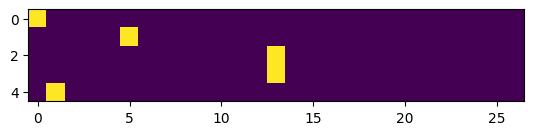

In [67]:
plt.imshow(xenc)
# you can check ([ 0,  5, 13, 13,  1])

* we always be careful about the data types because we dont wanna put integers value to neural network we want them as  a floating point
* we have a 5 examples

In [68]:
xenc.dtype


torch.int64

In [69]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # we can fix like that
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

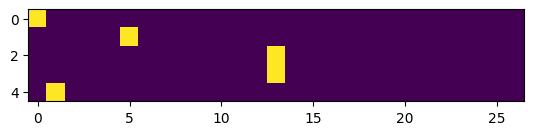

In [70]:
plt.imshow(xenc)

In [71]:
xenc.dtype

torch.float32

In [72]:
xenc.shape

torch.Size([5, 27])

In [73]:
W = torch.randn((27,1)) # random weight initialize for single neuron
xenc @ W 

tensor([[-0.6700],
        [-0.1839],
        [-0.6627],
        [-0.6627],
        [ 0.9460]])

* xenc is our input
* @ is a matrix multiplication
* xenc @ W ----> [5, 27] @ [27,1] = [5,1]
* we need a 27 neuron

In [74]:
W = torch.randn((27,27)) # random weight initialize for 27 neuron
xenc @ W 

tensor([[-1.2568,  0.5903, -0.4343,  1.8605,  0.7594, -1.4872,  1.0274,  0.0114,
         -0.9064, -0.9710, -1.2054, -0.1071, -1.5898,  0.6339,  0.0281, -0.3720,
         -0.5056, -0.1113, -0.3169, -0.2352, -1.0189,  0.9464,  0.8662, -0.0952,
         -0.1767, -0.3311,  0.3054],
        [-0.1844, -0.1628,  0.4044,  0.9722, -1.5269, -0.5536, -1.1246,  0.2902,
          1.4733, -0.2169, -0.9746,  1.5239, -0.6856,  1.7946, -1.0885, -0.0100,
         -0.2424, -0.9654,  0.8278,  0.8762, -0.0920,  0.7361, -0.1972,  0.2702,
          0.3075,  1.1123, -1.9971],
        [ 0.1403,  0.1414, -0.8767, -0.7701,  1.3131, -1.2823, -0.6521, -0.6949,
          1.7062,  0.0989, -0.6411, -0.4637,  0.0103,  0.5284, -1.2541,  0.1022,
         -0.3893, -1.0981, -0.2062, -0.9510, -0.0167, -1.6709,  0.9495,  0.9351,
         -0.7061,  0.3485,  0.1420],
        [ 0.1403,  0.1414, -0.8767, -0.7701,  1.3131, -1.2823, -0.6521, -0.6949,
          1.7062,  0.0989, -0.6411, -0.4637,  0.0103,  0.5284, -1.2541,  0.1022

* Previously, we had 27 inputs, and now we have 27 neurons in the hidden layer. We don't add an activation function or another layer; this is the simplest neural network, which is a single linear layer.


* In xenc @ 𝑊 we just have some negative and positive numbers, but we want those numbers to somehow represent the probabilities for the next character. Probabilities have a special structure: they are positive numbers and they sum to 1, which doesn't naturally come out of a neural network. Our 27 numbers give us log counts, so we must convert these numbers into the format we need.

In [75]:
(xenc @ W ).exp()

tensor([[0.2846, 1.8046, 0.6477, 6.4270, 2.1370, 0.2260, 2.7937, 1.0115, 0.4040,
         0.3787, 0.2996, 0.8984, 0.2040, 1.8849, 1.0285, 0.6893, 0.6032, 0.8947,
         0.7284, 0.7904, 0.3610, 2.5765, 2.3779, 0.9092, 0.8381, 0.7181, 1.3572],
        [0.8316, 0.8498, 1.4983, 2.6438, 0.2172, 0.5749, 0.3248, 1.3368, 4.3635,
         0.8050, 0.3774, 4.5900, 0.5038, 6.0172, 0.3367, 0.9900, 0.7847, 0.3808,
         2.2883, 2.4018, 0.9121, 2.0879, 0.8210, 1.3102, 1.3600, 3.0414, 0.1357],
        [1.1506, 1.1519, 0.4162, 0.4629, 3.7178, 0.2774, 0.5209, 0.4991, 5.5081,
         1.1039, 0.5267, 0.6289, 1.0103, 1.6962, 0.2853, 1.1076, 0.6775, 0.3335,
         0.8137, 0.3864, 0.9834, 0.1881, 2.5844, 2.5476, 0.4936, 1.4170, 1.1526],
        [1.1506, 1.1519, 0.4162, 0.4629, 3.7178, 0.2774, 0.5209, 0.4991, 5.5081,
         1.1039, 0.5267, 0.6289, 1.0103, 1.6962, 0.2853, 1.1076, 0.6775, 0.3335,
         0.8137, 0.3864, 0.9834, 0.1881, 2.5844, 2.5476, 0.4936, 1.4170, 1.1526],
        [1.3949, 0.7387,

* Using the exp function, we can convert negative numbers to positive values while keeping positive numbers positive. However, we now have values less than 1, which isn't ideal for our log counts.

In [76]:
logits = (xenc @ W ) # log -counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims = True) # normalize counts value
probs

tensor([[0.0086, 0.0542, 0.0195, 0.1932, 0.0642, 0.0068, 0.0840, 0.0304, 0.0121,
         0.0114, 0.0090, 0.0270, 0.0061, 0.0566, 0.0309, 0.0207, 0.0181, 0.0269,
         0.0219, 0.0238, 0.0108, 0.0774, 0.0715, 0.0273, 0.0252, 0.0216, 0.0408],
        [0.0199, 0.0203, 0.0359, 0.0633, 0.0052, 0.0138, 0.0078, 0.0320, 0.1044,
         0.0193, 0.0090, 0.1098, 0.0121, 0.1440, 0.0081, 0.0237, 0.0188, 0.0091,
         0.0548, 0.0575, 0.0218, 0.0500, 0.0196, 0.0314, 0.0325, 0.0728, 0.0032],
        [0.0364, 0.0364, 0.0132, 0.0146, 0.1175, 0.0088, 0.0165, 0.0158, 0.1741,
         0.0349, 0.0166, 0.0199, 0.0319, 0.0536, 0.0090, 0.0350, 0.0214, 0.0105,
         0.0257, 0.0122, 0.0311, 0.0059, 0.0817, 0.0805, 0.0156, 0.0448, 0.0364],
        [0.0364, 0.0364, 0.0132, 0.0146, 0.1175, 0.0088, 0.0165, 0.0158, 0.1741,
         0.0349, 0.0166, 0.0199, 0.0319, 0.0536, 0.0090, 0.0350, 0.0214, 0.0105,
         0.0257, 0.0122, 0.0311, 0.0059, 0.0817, 0.0805, 0.0156, 0.0448, 0.0364],
        [0.0370, 0.0196,

* now every row here to 1
* by the way all this operations are differentiable 
* now time is adjust the w to find best probs 

* SUMMARY
* * 1-we have some inputs (xs) and some labes for the correct next charachter in the sequence (ys) and these are int
* * 2-and generating 27 neuron weights (w) and each neuron receives 27 inputs
* * 3-after that we have to encode all of the inputs with one hot 
* * 4-after then multiple this in the first layer of a neural net to get logits
* * 5-exponentiate the logits to get fake counts sort of 
* * 6-normalize these counts to get probs (!!! step 5-6 called softmax)
* * step 3-4-5-6 called forward pass

* backpropagation time...
* our operation was multiplication addition exponention sum. we know how can backpropagate through them because everything here is a differentiable

In [77]:
nlls = torch.zeros(5) # inputs coming from 'emma'
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0086, 0.0542, 0.0195, 0.1932, 0.0642, 0.0068, 0.0840, 0.0304, 0.0121,
        0.0114, 0.0090, 0.0270, 0.0061, 0.0566, 0.0309, 0.0207, 0.0181, 0.0269,
        0.0219, 0.0238, 0.0108, 0.0774, 0.0715, 0.0273, 0.0252, 0.0216, 0.0408])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.006792300380766392
log likelihood: -4.9919657707214355
negative log likelihood: 4.9919657707214355
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0199, 0.0203, 0.0359, 0.0633, 0.0052, 0.0138, 0.0078, 0.0320, 0.1044,
        0.0193, 0.0090, 0.1098, 0.0121, 0.1440, 0.0081, 0.0237, 0.0188, 0.0091,
        0.0548, 0.0575, 0.0218, 0.0500, 0.0196, 0.0314, 0.0325, 0.0728, 0.0032])
label (actual next character): 13
probability assigned by the net to the the correct character:

* Now we have a loss function and this loss is only made up differentiable operations we can minimize the loss by tuning w.
* so then we can tune minimize the loss and find a good setting of w

* OPTIMIZATION

In [78]:
xs

tensor([ 0,  5, 13, 13,  1])

In [79]:
ys

tensor([ 5, 13, 13,  1,  0])

In [80]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [81]:
# forward  pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [82]:
probs.shape

torch.Size([5, 27])

In [83]:
probs[torch.arange(5), ys] # Possibility of outputs belonging to input

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150], grad_fn=<IndexBackward0>)

In [84]:
loss =- probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [85]:
# backward pass
W.grad = None # set to 0
loss.backward()

* Actually before getting started we set grads to 0 in micgrograd but in pytorc setting None more efficient
* when we apply loss.backward() all inputs effect this and has a grad value

In [86]:
W.data += -0.1 * W.grad

* now put it all together

In [87]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [88]:
# gradient descent
for k in range(10):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.768618583679199
3.3788065910339355
3.161090850830078
3.027186155319214
2.9344840049743652
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188305854797363


* There are some differences between bigrams and neural networks:

* Bigrams do not scale well, while the strength of neural networks is their scalability.
* When you push the weights (W) towards zero in the loss function, the distribution becomes smoother and more even.
* Now, we should talk about regularization.

In [89]:
# Training cycles, using the entire dataset -> 200 Epochs
for k in range(200):
    
    # Forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # one-hot encode the names
    logits = xenc @ W # logits, different word for log-counts
    counts = logits.exp() # 'fake counts', kinda like in  the N matrix of bigram
    probs = counts / counts.sum(1, keepdims=True) # Normal distribution probabilities (this is y_pred)
    loss = -probs[torch.arange(len(probs)), ys].log().mean() + 0.01 * (W**2).mean() # regularization loss
    print(f'Loss @ iteration {k+1}: {loss}')
    
    # Backward pass
    W.grad = None # Make sure all gradients are reset
    loss.backward() # Torch kept track of what this variable is, kinda cool
    
    # Weight update
    W.data += -50 * W.grad

Loss @ iteration 1: 2.696505308151245
Loss @ iteration 2: 2.6773722171783447
Loss @ iteration 3: 2.6608052253723145
Loss @ iteration 4: 2.6463515758514404
Loss @ iteration 5: 2.633664846420288
Loss @ iteration 6: 2.622471570968628
Loss @ iteration 7: 2.6125476360321045
Loss @ iteration 8: 2.6037068367004395
Loss @ iteration 9: 2.595794916152954
Loss @ iteration 10: 2.5886809825897217
Loss @ iteration 11: 2.5822560787200928
Loss @ iteration 12: 2.576429843902588
Loss @ iteration 13: 2.5711236000061035
Loss @ iteration 14: 2.566272735595703
Loss @ iteration 15: 2.5618228912353516
Loss @ iteration 16: 2.5577263832092285
Loss @ iteration 17: 2.5539441108703613
Loss @ iteration 18: 2.5504424571990967
Loss @ iteration 19: 2.5471925735473633
Loss @ iteration 20: 2.5441699028015137
Loss @ iteration 21: 2.5413525104522705
Loss @ iteration 22: 2.538721799850464
Loss @ iteration 23: 2.536262035369873
Loss @ iteration 24: 2.5339579582214355
Loss @ iteration 25: 2.5317976474761963
Loss @ iteration 

In [90]:
# Finally, sample from this neural network model
# (This structure is copied from the bigram approach)
g = torch.Generator().manual_seed(2147483642)

for i in range(5):
    out = []
    ix = 0
    while True:
        # ----------
        # BEFORE:
        #p = P[ix] # Bigram explicit probability approach
        # ----------
        # NOW:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True) # probabilities for next character
        # ----------
    
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        
        if ix == 0:
            break
    print(''.join(out))

ashan.
m.
asirrtai.
s.
naeryn.


# part 2

* * In this method (bigram), if we consider a single character at a time, there are 27 possible contexts. If we consider two characters, there are 27*27 possibilities. There are too many rows in this matrix with too few counts for each possibility, causing the method to become unmanageable and ineffective. Therefore, we will implement a Multilayer Perceptron (MLP) to predict the next character in the sequence. We will follow the approach outlined in this paper: [Bengio et al., 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf). While this paper uses a vocabulary of 17,000 words to build a word-level language model, we will use the same modeling approach for characters instead.
* * In this paper, a 17,000-word vocabulary is associated with a 30-dimensional feature vector for each word. This means each word is embedded in a 30-dimensional space, which is quite small for such a large vocabulary. Initially, these word embeddings are randomly distributed. However, as we tune these embeddings using backpropagation, some vectors will move closer together while others will move apart, reflecting their relationships and similarities. The paper uses a Multilayer Perceptron (MLP) to predict the next word based on previous words and trains the neural network by maximizing the log-likelihood.

In [91]:
from IPython import display
display.Image(url = 'https://production-media.paperswithcode.com/Screen_Shot_2020-05-26_at_2.17.37_PM.png')


* * In this diagram, we are using the previous three words to predict the next word (the fourth word) in the sequence. The lookup table is a matrix with 17,000 words, each represented by a 30-dimensional vector, converting each index to its corresponding embedding vector. We have an input layer of 30 neurons for each of the three words, totaling 90 values.

* * The size of the hidden layer is a hyperparameter, meaning it's a design choice left to the designer. We will experiment with various hidden layer sizes to evaluate their performance. For example, with 100 neurons in the hidden layer, each neuron would be fully connected to the 90 input values, using a tanh function as the activation function. The output layer consists of 17,000 neurons, one for each word in the vocabulary, and all are fully connected to the hidden layer neurons.

* * There is a significant competition between the hidden layer and the output layer due to the number of parameters. Our parameters include the weights and biases of both the output and hidden layers, as well as the embedding lookup table. All these parameters will be tuned during backpropagation.

* * Let's implement this setup...

In [92]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [93]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [94]:
len(words)

32033

In [95]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [96]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
# to guess the letter after the 3rd letter

X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


* finally dataset now looks like

In [97]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [98]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [99]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

* lets build the embedding lookup table C
* We have 27 characters, and we will embed them in a lower-dimensional space. In the paper, they have 17,000 words embedded in a 30-dimensional space. Since we only have 27 possible characters, let's start by embedding them in a space as small as 2 dimensions.

In [100]:
C = torch.randn((27,2))
C

tensor([[ 0.1964,  1.8770],
        [-0.0037,  1.1896],
        [ 2.4902, -1.5985],
        [ 0.1336,  0.0502],
        [-0.5807, -0.4280],
        [-1.3394,  1.2982],
        [ 0.2259, -0.4806],
        [-0.5708,  0.8802],
        [-0.7785, -0.8558],
        [-0.1191, -0.6641],
        [-0.4793,  1.7274],
        [-0.4015,  1.5511],
        [-0.7337, -0.1600],
        [ 1.7116, -0.6747],
        [-1.6324, -0.9180],
        [ 0.0510, -0.2382],
        [ 0.0292,  1.6245],
        [ 0.2525, -0.8892],
        [-0.6422,  0.6645],
        [-2.1560, -0.9408],
        [-1.4343,  0.4025],
        [-0.3548, -1.1166],
        [ 1.2105,  1.0205],
        [-0.2748, -0.1616],
        [-1.5535,  1.3781],
        [-1.7540, -0.0505],
        [ 0.4594, -0.2182]])

There are two different ways to handle the embedding process. The first method is to provide direct input to the C lookup table. The second method is to convert the input number to one-hot encoding and then input it to C. We will use the first method because it is faster.

For example, if our input is 5...

In [101]:
# 1st way
C[5]

tensor([-1.3394,  1.2982])

In [102]:
# 2nd way
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # num_classes is 27 because we have a 27 char

tensor([-1.3394,  1.2982])

In [103]:
C[[5,6,7]] # we can use like that pytorch idnexing is very flexible

tensor([[-1.3394,  1.2982],
        [ 0.2259, -0.4806],
        [-0.5708,  0.8802]])

In [104]:
C[torch.tensor([5,6,7])]

tensor([[-1.3394,  1.2982],
        [ 0.2259, -0.4806],
        [-0.5708,  0.8802]])

In [105]:
C[X].shape

torch.Size([32, 3, 2])

In [106]:
X[13,2] # index 13th second dimension value is 1

tensor(1)

In [107]:
C[1] == C[X[13,2]] # the equivalent of this value in the lookup table. you can verify manually in X

tensor([True, True])

In [108]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [109]:
W1 = torch.randn((6,100)) # we have a 2 dimnesional embeddings and have a three of them so 2x3=6, number of layer depends our choice which is 100
b1 = torch.randn(100) # bias also randomly

In [110]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

* there was a error because we have to change shapes

In [111]:
emb.shape 

torch.Size([32, 3, 2])

* we need to convert 3d embedding to 2d, one way to do this

In [112]:
torch.cat([emb[:,0,:], emb[:,1,:] , emb[:,2,:]],1) # 1 is cor dimension ???

tensor([[ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770, -1.3394,  1.2982],
        [ 0.1964,  1.8770, -1.3394,  1.2982,  1.7116, -0.6747],
        [-1.3394,  1.2982,  1.7116, -0.6747,  1.7116, -0.6747],
        [ 1.7116, -0.6747,  1.7116, -0.6747, -0.0037,  1.1896],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.0510, -0.2382],
        [ 0.1964,  1.8770,  0.0510, -0.2382, -0.7337, -0.1600],
        [ 0.0510, -0.2382, -0.7337, -0.1600, -0.1191, -0.6641],
        [-0.7337, -0.1600, -0.1191, -0.6641,  1.2105,  1.0205],
        [-0.1191, -0.6641,  1.2105,  1.0205, -0.1191, -0.6641],
        [ 1.2105,  1.0205, -0.1191, -0.6641, -0.0037,  1.1896],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770, -0.0037,  1.1896],
        [ 0.1964,  1.8770, -0.0037,  1.1896,  1.2105,  1.0205],
        [-0.0037,  1.1896,  1.2105,  1.0

* we have a problem. This code not generalize when we change the block_size this code will blow up
* there is a more efficient and dynamic way to do this(.view())

In [113]:
torch.cat(torch.unbind(emb,1),1).shape # does not depend to block_size

torch.Size([32, 6])

* how can we fix tensor view?

In [114]:
a = torch.arange(18)
print(f'a: {a}\n')
print(f'a.shape: {a.shape}\n',)
print(f'a.view(2,9): {a.view(2,9)} \n',)
print(f'a.view(3,2,3): {a.view(3,2,3)}\n',)

a: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

a.shape: torch.Size([18])

a.view(2,9): tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]]) 

a.view(3,2,3): tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]]])



* The view() function is very powerful. It lets us reshape the tensor in any way, as long as the total number of elements stays the same.
* The view so efficient for us because every tensor represented in the computer a.storage and its always one dimensional vector but when we called .view we just manipulated some attributies of that tensor. one dimnesional sequence is interpreted to be n dimensional tensor. in this part no memory is being changed or copied or moved
* look here for more: http://blog.ezyang.com/2019/05/pytorch-internals/

In [115]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.LongStorage of size 18]

In [116]:
print(emb.shape)
print(emb.view(32,6))

torch.Size([32, 3, 2])
tensor([[ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770, -1.3394,  1.2982],
        [ 0.1964,  1.8770, -1.3394,  1.2982,  1.7116, -0.6747],
        [-1.3394,  1.2982,  1.7116, -0.6747,  1.7116, -0.6747],
        [ 1.7116, -0.6747,  1.7116, -0.6747, -0.0037,  1.1896],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.0510, -0.2382],
        [ 0.1964,  1.8770,  0.0510, -0.2382, -0.7337, -0.1600],
        [ 0.0510, -0.2382, -0.7337, -0.1600, -0.1191, -0.6641],
        [-0.7337, -0.1600, -0.1191, -0.6641,  1.2105,  1.0205],
        [-0.1191, -0.6641,  1.2105,  1.0205, -0.1191, -0.6641],
        [ 1.2105,  1.0205, -0.1191, -0.6641, -0.0037,  1.1896],
        [ 0.1964,  1.8770,  0.1964,  1.8770,  0.1964,  1.8770],
        [ 0.1964,  1.8770,  0.1964,  1.8770, -0.0037,  1.1896],
        [ 0.1964,  1.8770, -0.0037,  1.1896,  1.2105,  1.0205],
        [-0.0037,

* 
In other words, in order to use the tensor in the size we want, we will use .view() and define the hidden layer again.

In [117]:
h = emb.view(32,6) @ W1 +b1

In [118]:
h.shape

torch.Size([32, 100])

In [119]:
# Let's make this definition dynamic
h = emb.view(-1,6) @ W1 +b1

* PyTorch reads the -1 and infers the correct dimension based on the other dimensions provided. For example, if (2x3) is already used, and you have 32 times 6 (or inputs times 6), PyTorch will determine the appropriate shape.

In [120]:
h = torch.tanh(emb.view(-1,6) @ W1 +b1)

* Due to the tanh function, our numbers are constrained to values between -1 and 1. The shape is 32 by 100,  which represents the hidden layer activations for each of our 32 examples.


In [121]:
print(h.shape)
print(b1.shape)

torch.Size([32, 100])
torch.Size([100])


* There's one more thing we need to be very careful with: broadcasting. In particular, we need to ensure that broadcasting behaves as expected. The shape of this tensor is 32 by 100, and the shape of the ones tensor is 100.
* We see that the addition will broadcast these two tensors, with the 32 by 100 tensor broadcasting to match the 100-dimensional tensor.
* 32,100 ---> 1,100 Broadcasting will align on the right, creating a fake dimension. This will turn the 100-dimensional tensor into a 1 by 100 row vector, which will then be vertically copied for each of the 32 rows, allowing for element-wise addition.
* In this case, the correct operation will occur because the same bias vector is added to all the rows of the matrix, which is what we want. It's always good practice to ensure this behavior.

In [122]:
W2 = torch.randn((100, 27)) # 100 inputs, 27 output neurons
b2 = torch.randn(27)

* Finally, let's create the final layer. We'll define w2 and b2, where the input size is 100 and the output size will be 27, corresponding to the 27 possible characters.

In [123]:
logits = h @ W2 +b2

In [124]:
# Softmax transforms outputs into probabilities
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
print(prob.shape)
print(prob[0].sum())

torch.Size([32, 27])
tensor(1.0000)


In [125]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

* Now, similar to the previous video, we want to index into the rows of the probability matrix and, in each row, extract the probability assigned to the correct character as indicated.

In [126]:
prob[torch.arange(32), Y]

tensor([3.1047e-05, 1.8037e-06, 7.2124e-04, 5.0775e-09, 7.0504e-08, 5.7419e-07,
        8.8706e-01, 3.2323e-10, 1.0355e-08, 1.3199e-06, 1.0401e-05, 1.4110e-04,
        6.0627e-13, 4.4914e-09, 2.5703e-11, 1.6655e-06, 2.1558e-07, 6.8901e-07,
        1.1434e-04, 2.2095e-09, 5.8159e-10, 2.9513e-12, 1.7354e-05, 1.3585e-07,
        4.2144e-02, 8.9232e-07, 2.0038e-05, 2.5824e-05, 1.1309e-05, 8.0233e-09,
        2.9855e-06, 2.9969e-03])

* This provides the current probabilities assigned by the neural network, based on its weight settings, to the correct character in the sequence.
* You can see that the probabilities look reasonable for some characters (like this one, which is around 0.2), but they don't look very good for many other characters.
* The network currently considers some characters extremely unlikely. However, since we haven't trained the neural network yet, this will improve. Ideally, all these probabilities should be 1, indicating that we are correctly predicting the next character.

In [127]:
# We want the average log probability across all 32 inputs to be our loss
loss = -prob[torch.arange(32), Y].log().mean()
print(loss.item()) # This is to be minimized

14.382123947143555


* The following is a simplified version of the code provided above:








In [128]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [129]:
# Let's re-initialize the weights and biases
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2]            # Group all parameters into a single structure.

In [130]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [131]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss=F.cross_entropy(logits, Y)
loss

tensor(17.7697)

* this is just classification. Many people use classification, which is why PyTorch provides the functional.cross_entropy function to compute this more efficiently. We can simply call f.cross_entropy, passing in the logits and the target array y, and it will calculate the same loss. In fact, we can replace the custom implementation with this function and achieve the same result.
* There are several good reasons to prefer f.cross_entropy over a custom implementation. Firstly, using f.cross_entropy prevents PyTorch from creating numerous intermediate tensors, which can be inefficient. Instead, PyTorch optimizes operations, often using fused kernels that evaluate expressions more efficiently. Secondly, the backward pass is more efficient with f.cross_entropy, not just because of fused kernels but also due to its simpler analytical and mathematical implementation.
 * Secondly, f.cross_entropy is often more numerically stable. For example, consider logits of -2, 3, -3, 0, and 5. When we take the exponent of these logits and normalize them to sum to 1, it shows how f.cross_entropy handles numerical stability effectively.If the value of our input numbers changes significantly, the result will be undesirable.
An example is given in the cell below
* There are many good reasons to use cross_entropy. Firstly, the forward pass can be much more efficient. Secondly, the backward pass can also be more efficient. Additionally, numerical stability is significantly improved.

In [132]:
logits = torch.tensor([-2,3,-3,0,5])
counts = logits.exp()
probs = counts / counts.sum()
print(f'first probs is {probs}')
logits = torch.tensor([-2,3,-3,0,100])
counts = logits.exp()
probs = counts / counts.sum()
print(f'second probs is {probs}')

first probs is tensor([7.9757e-04, 1.1837e-01, 2.9341e-04, 5.8933e-03, 8.7465e-01])
second probs is tensor([0., 0., 0., 0., nan])


In [133]:
for p in parameters:
    p.requires_grad = True # important !!!

In [134]:
# lets build again..
for _ in range (10):
    #forward pass
    emb = C[X] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

17.76971435546875
13.656402587890625
11.298770904541016
9.452458381652832
7.984263896942139
6.891321659088135
6.100015163421631
5.452036380767822
4.898151874542236
4.414664268493652


* If our iterator value were 1000, we would encounter an overfitting situation because we have many parameters (3,481 in this case) but only 32 examples.

In [135]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2] 
for p in parameters:
    p.requires_grad = True # important !!!
for _ in range (1000):
    #forward pass
    emb = C[X] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.2561379075050354


We're unable to achieve exactly zero loss. To understand why, let's examine the logits being predicted. By looking at the maximum values along the first dimension in PyTorch, we can see both the maximum values and their indices. The indices are often close to the labels but sometimes differ. For example, the predicted index might be 19 while the label is 5. This discrepancy occurs because the first example may be supposed to predict 'e,' but it could also predict 'o,' 'i,' or 's.' Thus, multiple outcomes are possible for the same input, preventing us from completely overfitting and achieving zero loss. However, when there is a unique input for a unique output, we overfit and get the correct result. Now, we just need to ensure we read in the full dataset and optimize the neural network.

In [136]:
logits.max(1)

torch.return_types.max(
values=tensor([13.3348, 17.7905, 20.6014, 20.6119, 16.7355, 13.3348, 15.9985, 14.1724,
        15.9147, 18.3614, 15.9396, 20.9265, 13.3348, 17.1089, 17.1319, 20.0601,
        13.3348, 16.5891, 15.1017, 17.0580, 18.5862, 15.9670, 10.8740, 10.6872,
        15.5056, 13.3348, 16.1794, 16.9743, 12.7427, 16.2008, 19.0846, 16.0195],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [137]:


# build the dataset and run with ALL dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
# to guess the letter after the 3rd letter

X, Y = [], []
for w in words:

    
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

print(X.shape,Y.shape)


g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True


torch.Size([228146, 3]) torch.Size([228146])
3481


In [138]:
for _ in range (10):
    #forward pass
    
    emb = C[X] # 
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad


19.505229949951172


17.084487915039062
15.776531219482422
14.833338737487793
14.002596855163574
13.253255844116211
12.579915046691895
11.983097076416016
11.470491409301758
11.05185604095459


* You'll notice that each iteration takes quite a bit of time because we're processing 220,000 examples in each forward and backward pass. To address this, we can use mini-batching. In practice, people perform forward and backward passes and updates on smaller batches of data. We'll randomly select a portion of the dataset as a mini-batch, then perform the forward, backward, and update steps on just that mini-batch, iterating over these mini-batches.
* when we apply arrangements we have to always define parameters. Because when we trained model all parameters are tuned. so this is not good for fair comparison or see the difference in result


In [139]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [140]:
for _ in range (10):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

20.021865844726562
15.163591384887695
12.232786178588867
12.900798797607422
15.135669708251953
11.78172779083252
14.791145324707031
10.782867431640625
11.77491283416748
11.610196113586426


* This way, we can run many examples quickly and decrease the loss much faster. Although the quality of our gradient is lower when dealing with mini-batches, the direction is still useful even when estimated from only 32 examples. It's better to have an approximate gradient and take more steps than to evaluate the exact gradient and take fewer steps. This approach works well in practice
* lets look back learning rate  optimziation, first of all we reset the all parameters

In [141]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [142]:
lre = torch.linspace(-3,0, 1000)
lrs = 10 ** lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [143]:
lr_i = []
loss_i = []
for i in range (1000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    lr_i.append(lre[i]) 
    loss_i.append(loss.item())

18.940847396850586
17.234683990478516
16.920934677124023
20.51490020751953
19.690006256103516
19.922494888305664
21.28386878967285
19.174949645996094
18.845298767089844
20.949142456054688
17.720319747924805
20.624719619750977
19.770652770996094
18.23843765258789
22.65806007385254
15.818674087524414
16.727191925048828
17.585508346557617
16.909578323364258
16.239612579345703
18.931194305419922
19.550411224365234
20.53691291809082
22.281801223754883
15.594038963317871
19.206958770751953
19.221614837646484
18.37530517578125
16.828786849975586
18.662708282470703
16.993743896484375
16.934816360473633
20.337413787841797
16.803651809692383
16.170772552490234
19.84532356262207
18.769254684448242
18.524532318115234
16.43061637878418
13.936785697937012
18.6380615234375
18.503637313842773
19.938064575195312
18.281387329101562
16.188446044921875
19.76719093322754
17.41565704345703
16.263708114624023
18.543123245239258
18.84235382080078
18.258216857910156
18.711833953857422
16.490100860595703
17.799

*  The reason why we use Lre[i] instead of lr  is that the values ​​to the power of 10 are written on the x-axis in the graph we will draw.
 * lr_i.append(lre[i])

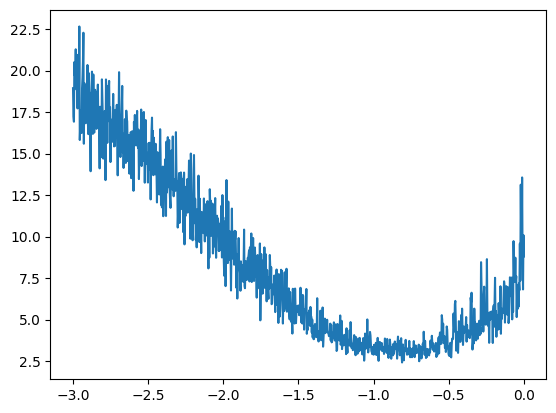

In [144]:
plt.plot(lr_i,loss_i)

* A learning rate around  0.1 is usually a good setting. In our initial setup, 0.1 was a fairly effective learning rate. This is roughly how you would determine it.

In [145]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [146]:

for i in range (1000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
 

20.721452713012695
17.64572525024414
16.482635498046875
14.388294219970703
13.54675006866455
12.877803802490234
13.829273223876953
12.499701499938965
9.663113594055176
11.379215240478516
11.740530014038086
11.850550651550293
9.674104690551758
8.836165428161621
8.413898468017578
9.892440795898438
9.231436729431152
8.869060516357422
11.291104316711426
6.255683898925781
7.6485915184021
7.215471267700195
9.540700912475586
9.391793251037598
6.0391950607299805
6.816508769989014
7.5931501388549805
9.239055633544922
5.779603481292725
7.366330146789551
5.802003383636475
7.8085551261901855
6.891623020172119
4.631863117218018
6.227510929107666
6.966742038726807
6.471100330352783
4.891592979431152
7.79658317565918
8.065340042114258
6.807788372039795
6.058884143829346
5.719854354858398
6.469156265258789
6.038421630859375
4.4958271980285645
5.239500522613525
4.498910903930664
5.147900581359863
5.298001766204834
4.972182273864746
5.67858362197876
5.904750823974609
4.730849742889404
4.7483439445495605

* You first find a decent learning rate using the approach in the code above. Then, you start with that learning rate and train for a while. Toward the end, you can apply learning rate decay, reducing the learning rate by a factor of 10 and taking a few more steps. This helps in getting a well-trained network.


* As you add more neurons and parameters, the neural network's capacity to overfit the training set increases. This means the loss on the training set can become very low, even zero, indicating that the model is merely memorizing the training data. Consequently, when you sample from the model, it will reproduce the training data exactly, without generating any new data. Moreover, the loss on a separate evaluation set may be very high, revealing that the model does not generalize well. To address this, it is standard practice to split your dataset into three parts: the training set, the development (validation) set, and the test set.
* Eighty percent of your dataset is used for the training set to optimize the model's parameters through gradient descent. Ten percent is used for the development (or validation) split to tune the hyperparameters, such as the hidden layer size, embedding size, and regularization strength. You can try different settings and see which works best on the validation split. The training split trains the parameters, while the validation split helps tune the hyperparameters. The test split, the remaining ten percent, evaluates the model's performance at the end. You should only evaluate the loss on the test set sparingly, as frequent evaluation can lead to overfitting. Let's split our training data into train, dev, and test sets, then train on the train set and evaluate on the test set very sparingly.

In [147]:
# training split, valid siplit and test split
# %80, %10, %10
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?

  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtrain, Ytrain = build_dataset(words[:n1])
Xvalid, Yvalid = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [152]:
print(f'train samples: {Xtrain.shape[0]}')
print(f'train samples: {Xvalid.shape[0]}')
print(f'train samples: {Xtest.shape[0]}')

train samples: 182625
train samples: 22655
train samples: 22866


In [153]:
Xtrain.shape, Ytrain.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [183]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [184]:
lre = torch.linspace(-3,0, 1000)
lrs = 10 ** lre


In [185]:
lr_i = []
loss_i = []
for i in range (30000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    # lr_i.append(lre[i]) 
    # loss_i.append(loss.item())

In [186]:


print(loss.item())

2.0367350578308105


In [187]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4381, grad_fn=<NllLossBackward0>)

In [188]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4336, grad_fn=<NllLossBackward0>)

* We see that the training and dev losses are about equal, indicating that we're not overfitting. This model isn't powerful enough to purely memorize the data, and we are actually underfitting because the training and dev/test losses are roughly equal. This usually means our network is too small. To improve performance, we should scale up the size of the neural net. Let's increase the size of the neural net to address this.
* The easiest way to scale up is to increase the number of neurons in the hidden layer. Currently, it has 100 neurons, so let's increase it to 300. This means we'll also have 300 biases, and 300 inputs into the final layer. After initializing our neural net with these changes, we'll have ten thousand parameters instead of three thousand.

In [200]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,300), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((300), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((300,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

10281


In [201]:
lr_i = []
loss_i = []
stepi = []
for i in range (70000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.05
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    stepi.append(i) 
    loss_i.append(loss.item())

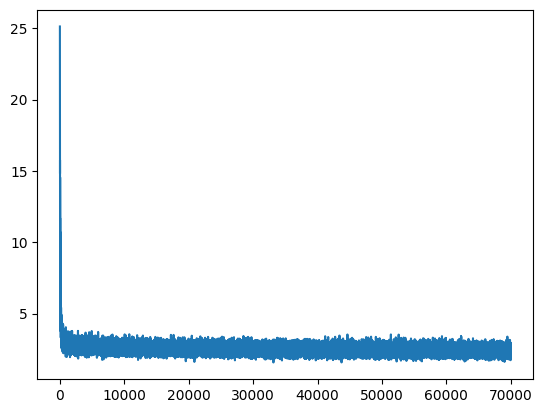

In [202]:
plt.plot(stepi,loss_i)

In [203]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4070, grad_fn=<NllLossBackward0>)

In [204]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4053, grad_fn=<NllLossBackward0>)

In [ ]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4070, grad_fn=<NllLossBackward0>)

In [ ]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4053, grad_fn=<NllLossBackward0>)

* These results are better than the results of the small size model. The reason why we increased the number of epochs is that the model needs more epochs as the number of parameters increases.
 * We can try different things to reduce the loss. one of them is embedding size increase

In [228]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,10), generator=g)        # 27 characters, has 10 dimensions each
W1 = torch.randn((30,200), generator=g)      # 3 characters, each with 10 embedding values, are used as inputs to 200 neurons.
b1 = torch.randn((200), generator=g)        # 200 biases added to the 200 neuron outputs
W2 = torch.randn((200,27), generator=g)     # 200 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

11897


In [244]:
lr_i = []
loss_i = []
stepi = []
for i in range (100000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,30) @ W1 +b1) # its 30 because 3 characters, each with 10 embedding values 3*10
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    stepi.append(i) 
    loss_i.append(loss.log10().item()) # it will looking good on plot

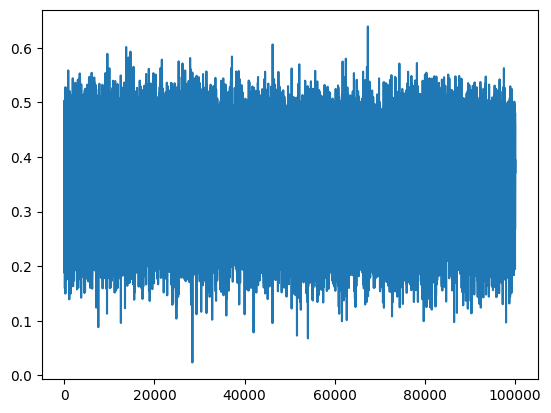

In [240]:
plt.plot(stepi,loss_i)

* its looking thick because of bath size we can decrease it

In [245]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.2161, grad_fn=<NllLossBackward0>)

In [246]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.2367, grad_fn=<NllLossBackward0>)

* the clean code in above

In [247]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtrain.shape[0], (32,))
  
  # forward pass
  emb = C[Xtrain[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytrain[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  loss_i.append(loss.log10().item())

#print(loss.item())

NameError: name 'Xtr' is not defined

In [248]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amorie.
khiwmiri.
thiy.
salans.
emmahnen.
den.
rha.
kaeli.
nermaritceriivin.
leigph.
brondin.
quint.
sulin.
alianni.
wantrondearynix.
kae.
pirran.
edde.
oia.
